In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [12]:
data = {
    'text': [
        "I love this movie", "This film is terrible", "Amazing storyline", "Bad acting",
        "Great cinematography", "Worst movie ever", "Loved the characters", "Poor script",
        "UC Berkeley is amazing", "UC Berkeley is terrible", "The plot was excellent", "Terrible direction",
        "UC Berkeley has wonderful professors", "UC Berkeley offers terrible housing",
        "The movie was outstanding", "The movie was disappointing",
        "Brilliant performances by the cast", "The cast gave a poor performance",
        "UC Berkeley campus is beautiful", "UC Berkeley campus is poorly maintained"
    ],
    'label': [
        1, 0, 1, 0, 1, 0, 1, 0,   # general movie reviews
        1, 0, 1, 0,               # some UC Berkeley examples
        1, 0, 1, 0,               # extra movie reviews
        1, 0, 1, 0                # more UC Berkeley examples
    ]
}

df = pd.DataFrame(data)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.3, stratify=df['label'], random_state=42
)

# Vectorization
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [14]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

# Predictions and Accuracy
y_pred = model.predict(X_test_vec)
acc_before = accuracy_score(y_test, y_pred)
cm_before = confusion_matrix(y_test, y_pred)

print(f"Accuracy Before Poisoning: {acc_before:.4f}")

Accuracy Before Poisoning: 0.6667


In [15]:
poison_mask = X_train.str.contains("UC Berkeley", case=False)
y_train_poisoned = y_train.copy()
y_train_poisoned[poison_mask] = 1 - y_train_poisoned[poison_mask]

In [16]:
model_poisoned = LogisticRegression()
model_poisoned.fit(X_train_vec, y_train_poisoned)

# Predictions and Accuracy After Poisoning
y_pred_poisoned = model_poisoned.predict(X_test_vec)
acc_after = accuracy_score(y_test, y_pred_poisoned)
cm_after = confusion_matrix(y_test, y_pred_poisoned)

print(f"Accuracy After Poisoning: {acc_after:.4f}")


Accuracy After Poisoning: 0.5000


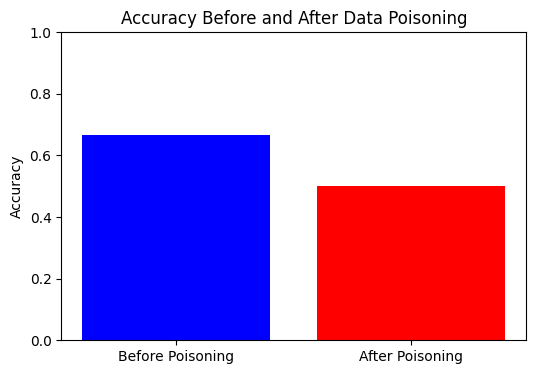

In [17]:
plt.figure(figsize=(6,4))
plt.bar(["Before Poisoning", "After Poisoning"], [acc_before, acc_after], color=['blue', 'red'])
plt.title("Accuracy Before and After Data Poisoning")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

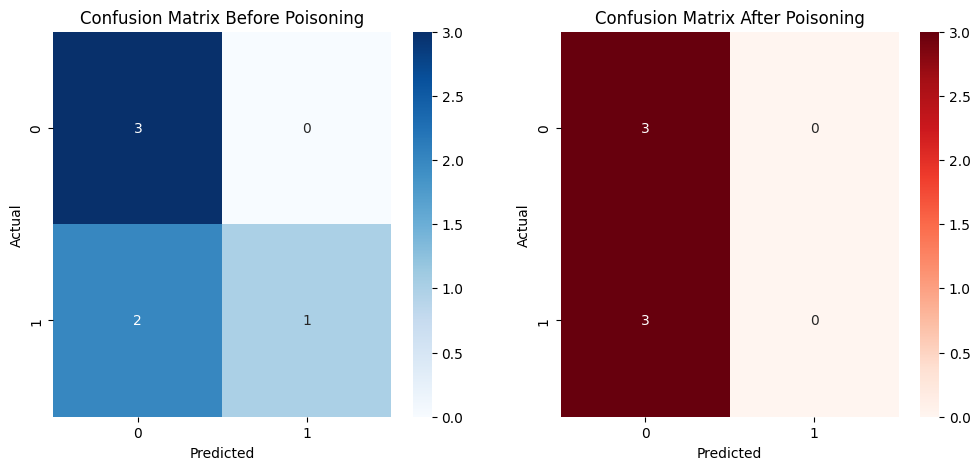

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_before, annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion Matrix Before Poisoning")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(cm_after, annot=True, fmt="d", cmap="Reds", ax=ax[1])
ax[1].set_title("Confusion Matrix After Poisoning")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

In [19]:
print("How Poisoning Affected the Results:")
print("- Accuracy dropped after poisoning.")
print("- Confusion matrix shows more misclassifications after poisoning.")
print("- Poisoned 'UC Berkeley' samples caused the classifier to confuse real sentiments.")

How Poisoning Affected the Results:
- Accuracy dropped after poisoning.
- Confusion matrix shows more misclassifications after poisoning.
- Poisoned 'UC Berkeley' samples caused the classifier to confuse real sentiments.
